### Project 3 — Trade Data Discrepancy Analysis

Exploring UN Comtrade mirror-statistics discrepancies: how the same trade flow gets reported
differently by the two countries involved.

Comparing 4 partners against Poland (2024): Germany and Netherlands (intra-EU, Intrastat-driven
reporting) vs. UK and USA (extra-EU, customs-declaration-driven reporting) — chosen depth-first
rather than a full EU-wide network, with commodity-level (HS2) detail as the next layer.

## Setup

In [1]:
import time
import os
import requests
import pandas as pd
from dotenv import load_dotenv
import matplotlib.pyplot as plt 
import seaborn as sns

pd.set_option('display.float_format', lambda x: f'{x:.2f}')
load_dotenv()

True

In [2]:
comtrade_url = "https://comtradeapi.un.org/data/v1/get/C/A/HS"

comtrade_poland = "616"
comtrade_partners = {
    "Germany": "276",
    "Netherlands": "528",
    "United Kingdom": "826",
    "United States": "842"
}
comtrade_country_map = {
        276: "DE",
        616: "PL",
        528: "NL",
        826: "GB",
        842: "US"
    }

hs2_mapping = {
        "01": "Live Animals",
        "02": "Meat and Edible Meat Offal",
        "03": "Fish and Crustaceans, Mollusks, and Other Aquatic Invertebrates",
        "04": "Dairy Products: Birds’ Eggs: Natural Honey: Edible Products of Animal Origin, Not Elsewhere Specified or Included",
        "05": "Products of Animal Origin, Not Elsewhere Specified or Included",
        "06": "Live Trees and Other Plants: Bulb, Roots and the Like: Cut Flowers and Ornamental Foliage",
        "07": "Vegetable Seeds; Edible Vegetables and Certain Roots and Tubers",
        "08": "Edible Fruit and Nuts; Peel of Citrus Fruit or Melons",
        "09": "Coffee, Tea, Mate, and Spices",
        "10": "Cereals",
        "11": "Products of the Milling Industry; Malt; Starches; Inulin Wheat Gluten",
        "12": "Oil Seeds and Oleaginous Fruits: Miscellaneous Grains, Seeds, and Fruit: Industrial or Medicine Plante; Straw and Fodder",
        "13": "Lac; Gums; Resins and Other Vegetable Saps and Extracts",
        "14": "Vegetable Plaiting Material; Vegetable Products Not Elsewhere Specified or Included",
        "15": "Animal or Vegetable Fats and Oils and their Cleavage Products, Prepared Animal Fats, Animal or Vegetable Waxes",
        "16": "Preparations of Meat, of Fish, or of Crustaceans, Mollusks, or Other Aquatic Invertebrates",
        "17": "Sugars and Sugar Confectionery",
        "18": "Cocoa and Cocoa Preparations",
        "19": "Preparations of Cereals, Flour, Starch, or Milk; Pastrycooks' Products",
        "20": "Preparations of Vegetables, Fruit, Nuts, or Other Parts of Plants",
        "21": "Miscellaneous Edible Preparations",
        "22": "Beverages, Spirits, and Vinegar",
        "23": "Residues and Waste from the Food Industries: Prepared Animal Fodder",
        "24": "Tobacco and Manufactures; Tobacco Substitutes",
        "25": "Salt: Sulphur; Earths and Stone: Plastering Materials, Lime, and Cement",
        "26": "Ores, Slag, and Ash",
        "27": "Mineral Fuels, Mineral Oils, and Products of Their Distillation; Bituminous Substances, Mineral Waxes",
        "28": "Inorganic Chemicals: Organic or Inorganic Compounds of Precious Metals, of Rare-Earth Metals, of Radioactive Elements of Isotopes",
        "29": "Organic Chemicals",
        "30": "Pharmaceutical Products",
        "31": "Fertilizers",
        "32": "Dyeing Extracts; Tannins and Their Derivatives: Dyes, Pigments, and Other Coloring Matter; Paints and Varnishes: Putty and Other Mastics: Inks",
        "33": "Essential Oils and Resinoids; Perfumery Cosmetic or Toilet Preparations",
        "34": "Soap. Organic Surface-Active Agents, Washing Preparations, Lubricating Preparations, Artificial Waxes, Prepared Waxes, Polishing or Sourcing Preparations, Candles and Similar Articles, Modelling Pastes, “Dental Waxes” and Dental Preparations",
        "35": "Albuminoidal Substances; Modified Starches; Glues; Enzymes",
        "36": "Explosives; Pyrotechnic Products; Matches; Pyrophoric Alloys: Certain Combustible Preparations",
        "37": "Photographic or Cinematographic Goods",
        "38": "Miscellaneous Chemical Products",
        "39": "Plastics and Articles Thereof",
        "40": "Rubber and Articles Thereof",
        "41": "Raw Hides and Skins (Other Than Furskins) and Leather",
        "42": "Articles of Leather; Saddlery and Harness; Travel Goods, Handbags, and Similar Containers; Articles of Animal Gut (Other Than Silk-Worm Gut)",
        "43": "Furskins and Artificial Fur; Manufactures Thereof",
        "44": "Wood and Articles of Wood; Wood Charcoal",
        "45": "Cork and Articles or Cork",
        "46": "Manufactures of Straw, of Esparto, or of Other Plaiting Materials; Basketware and Wickerwork",
        "47": "Pulp of Wood or of Other Fibrous Cellulosic Material; Recovered (Waste and Scrap) Paper or Paperboard",
        "48": "Paper and Paperboard; Article of Paper Pulp, of Paper or of Paperboard Currency Paper (Water-Mark Bank Note Paper)",
        "49": "Printed Books, Newspapers, Pictures, and Other Products of the Printing Industry; Manuscripts, Typescripts, and Plans",
        "50": "Silk",
        "51": "Wool, Fine or Coarse Animal Hair, Hose Hair Yarn, and Woven Fabric",
        "52": "Cotton",
        "53": "Other Vegetable Textile Fibers; Paper Yarn and Woven Fabrics of Paper Yarn",
        "54": "Man-made Filaments",
        "55": "Man-made Staple Fibers",
        "56": "Wadding, Felt, and Nonwovens: Special Yarns, Twine, Cordage, Ropes, and Cables and Articles Thereof",
        "57": "Carpets and Other Textile Floor Coverings",
        "58": "Special Woven Fabrics; Tufted Textile Fabrics; Lace; Tapestries; Trimmings: Embroidery",
        "59": "Impregnated, Coated, Covered or Laminated Textile Fabrics; Textile Articles of a Kind Suitable for Industrial Use",
        "60": "Knitted or Crocheted Fabrics",
        "61": "Articles of Apparel and Clothing Accessories, Kitted or Crocheted",
        "62": "Articles of Apparel and Clothing Accessories Not Knitted or Crocheted",
        "63": "Textiles, made-up articles, sets, worn clothing and worn textile articles, rags",
        "64": "Footwear, Gaiters, and the Like; Parts of Such Articles",
        "65": "Headgear and Parts Thereof",
        "66": "Umbrellas, Sun Umbrellas. Walking-Sticks, Seat-Sticks, Whips. Riding-Crops, and Parts Thereof",
        "67": "Prepared Feathers and Down and Articles Made of Feathers or of Down: Artificial Flowers; Articles of Human Hair",
        "68": "Articles of Stone. Plaster, Cement, Asbestos, Mica, or Similar Materials",
        "69": "Ceramic Products",
        "70": "Glass and Glassware",
        "71": "Natural or Cultured Pearls, Precious or Semi-Precious Stones, Precious Metals, Metals Clad with Precious Metal, and Articles Thereof: Imitation Jewelry; Coin",
        "72": "Iron and Steel",
        "73": "Articles of Iron or Steel",
        "74": "Copper and Articles Thereof",
        "75": "Nickel and Articles Thereof",
        "76": "Aluminium and Articles Thereof",
        "77": "(Reversed for Possible Future Use in the Tariff)",
        "78": "Lead and Articles Thereof",
        "79": "Zinc and Articles Thereof",
        "80": "Tin and Articles Thereof",
        "81": "Other Base Metals; Cements Articles and Thereof",
        "82": "Tools, Implements, Cutlery, Spoons and Forks, of Base",
        "83": "Metal. Parts Thereof Base Metal Miscellaneous Articles of Base Metal",
        "84": "Nuclear Reactors, Boilers, Machinery and Mechanical Appliances, Parts Thereof",
        "85": "Electrical Machinery and Equipment and Parts Thereof; Sound Recorders and Reproducers, Television Image and",
        "86": "Equipment",
        "87": "Vehicles Other Than Railway or Tramway Rolling-Stock, and Parts and Accessories Thereof",
        "88": "Aircraft, Spacecraft, and Parts Thereof",
        "89": "Ships, Boats, and Floating Structures",
        "90": "Optical, Photographic, Cinematographic. Measuring, Checking, Precision. Medical, or Surgical Instruments and Apparatus; Parts and Accessories Thereof",
        "91": "Clocks and Watches and Part Thereof",
        "92": "Musical Instruments Parts and Accessories of Such Articles",
        "93": "Arms and Ammunition; Parts and Accessories Thereof",
        "94": "Furniture: Bedding, Mattresses, Mattresses Supports, Cushions, and Similar Stuffed Furnishings; Lamps and Lighting Fittings, Not Elsewhere Specified or Included: Illuminated Signs, Illuminated Name-Plates and the Like; Prefabricated Building",
        "95": "Toys, Games, and Sports Requisites: Parts and Accessories Thereof",
        "96": "Miscellaneous Manufactured Articles",
        "97": "Works of Art, Collectors’ Pieces, and Antiques",
        "98": "Trading Products Special and Not Otherwise Classified"
}

## API helper functions

Three layers, each used by the one above it:
- `get_comtrade()` — transport only: makes the request, retries on rate limits/timeouts/server errors.
- `fetch_trade_comtrade()` — one query, one tidy row. Raises `QuotaExceededError` if the daily quota is out,
  returns `None` if the query is valid but has no data (e.g. an HS chapter with zero trade).
- `fetch_hs2_breakdown_comtrade()` — loops `fetch_trade()` over all 97 HS2 chapters for one reporter/partner/flow,
  checkpointing progress to disk so a crash or a quota cutoff doesn't lose completed chapters.

In [3]:
class QuotaExceededError(Exception):
    pass

In [4]:
def get_comtrade(comtrade_url, params, max_retries=5):
    """GET request to the Comtrade API with retry handling."""

    headers = {
        "Ocp-Apim-Subscription-Key": os.environ["COMTRADE_KEY"]
    }

    for attempt in range(max_retries):
        try:
            response = requests.get(
                comtrade_url,
                params=params,
                headers=headers,
                timeout=60
            )

            if response.status_code == 200:
                return response

            if response.status_code in {429, 500, 502, 503, 504}:
                wait_time = 3 * (attempt + 1)
                print(f"HTTP {response.status_code}. Attempt {attempt + 1}/{max_retries}. Waiting {wait_time}s...")
                time.sleep(wait_time)
                continue

            return response

        except requests.exceptions.Timeout:
            wait_time = 3
            print(f"Timeout. Attempt {attempt + 1}/{max_retries}. Waiting {wait_time}s...")
            time.sleep(wait_time)

        except requests.exceptions.RequestException as e:
            print(f"Request error: {e}. Attempt {attempt + 1}/{max_retries}.")
            time.sleep(3)

    raise RuntimeError(f"Comtrade API request failed after {max_retries} attempts.")

In [5]:
def fetch_trade_comtrade(reporter, partner, flow, period="2024", cmd_code="TOTAL"):
    params = {
        "period": period,
        "reporterCode": reporter,
        "cmdCode": cmd_code,
        "flowCode": flow,
        "partnerCode": partner,
        "partner2Code": "0",
        "motCode": "0",
        "customsCode": "C00",
        "maxRecords": 500
    }
    response = get_comtrade(comtrade_url, params)
    data = response.json()

    if data.get("statusCode") == 403:
        raise QuotaExceededError(data.get("message", "Quota exhausted"))

    if "data" not in data or len(data["data"]) == 0:
        return None

    record = data["data"][0]
    
    record["reporterCode"] = (
        comtrade_country_map.get(record["reporterCode"],
        record["reporterCode"])
    )
    record["partnerCode"] = (
        comtrade_country_map.get(record["partnerCode"],
        record["partnerCode"])
    )
    return {
        "reporterCode": record["reporterCode"],
        "partnerCode": record["partnerCode"],
        "flowCode": record["flowCode"],
        "primaryValue": record["primaryValue"],
        "fobvalue": record["fobvalue"],
        "cifvalue": record["cifvalue"]
    }



In [6]:
def fetch_hs2_breakdown_comtrade(reporter, partner, flow):
    checkpoint_file = f"hs2_{flow}_{reporter}_{partner}.csv"

    if os.path.exists(checkpoint_file):
        records = pd.read_csv(checkpoint_file, dtype={"hs2": str}).to_dict("records")
    else:
        records = []

    for chapter in [f"{i:02d}" for i in range(1, 98)]:
        already_done = {r["hs2"] for r in records}
        if chapter in already_done:
            continue

        try:
            row = fetch_trade_comtrade(reporter, partner, flow, cmd_code=chapter)
        except QuotaExceededError as e:
            print(f"Quota exhausted: {e}")
            break

        if row is None:
            continue

        records.append({**row, "hs2": chapter})
        pd.DataFrame(records).to_csv(checkpoint_file, index=False)
        time.sleep(2)

    return pd.DataFrame(records).drop_duplicates(subset="hs2", keep="last")

## Mirror pair: Poland <-> Germany, 2024, TOTAL (intra-EU)

Both directions go through `fetch_trade_comtrade()`, which always fixes `customsCode="C00"` internally —
so both sides are guaranteed the same aggregate level, no separate guardrail needed.

In [7]:
export_row = fetch_trade_comtrade(comtrade_poland, comtrade_partners["Germany"], "X")
import_row = fetch_trade_comtrade(comtrade_partners["Germany"], comtrade_poland, "M")

gap = export_row["primaryValue"] - import_row["primaryValue"]
discrepancy_pct = abs(gap) / ((export_row["primaryValue"] + import_row["primaryValue"]) / 2) * 100

print(f"Poland -> Germany exports (FOB): {export_row['primaryValue']:,.0f}")
print(f"Germany <- Poland imports (CIF): {import_row['primaryValue']:,.0f}")
print(f"Signed gap: {gap:,.0f}")
print(f"Symmetric discrepancy: {discrepancy_pct:.1f}%")

HTTP 429. Attempt 1/5. Waiting 3s...
Poland -> Germany exports (FOB): 102,929,212,719
Germany <- Poland imports (CIF): 81,013,450,966
Signed gap: 21,915,761,753
Symmetric discrepancy: 23.8%


## Four-partner comparison

Same mirror-pair idea, run across all 4 partners at once: fetch both directions for each,
reshape so each partner's export and import side sit in the same row, then compute the gap.

In [8]:
records = []

for name, code in comtrade_partners.items():
    print(f"Fetching {name} import...")
    records.append(fetch_trade_comtrade(code, comtrade_poland, "M"))
    time.sleep(1)
    print(f"Fetching {name} export...")
    records.append(fetch_trade_comtrade(comtrade_poland, code, "X"))
    time.sleep(1)
    print(f"Fetching {name} import...")
    records.append(fetch_trade_comtrade(comtrade_poland, code, "M"))
    time.sleep(1)
    print(f"Fetching {name} export...")
    records.append(fetch_trade_comtrade(code, comtrade_poland, "X"))
    time.sleep(1)
print(f"Done — {len(records)} records collected")

Fetching Germany import...
Fetching Germany export...
Fetching Germany import...
Fetching Germany export...
Fetching Netherlands import...
Fetching Netherlands export...
Fetching Netherlands import...
Fetching Netherlands export...
Fetching United Kingdom import...
Fetching United Kingdom export...
Fetching United Kingdom import...
Fetching United Kingdom export...
Fetching United States import...
Fetching United States export...
Fetching United States import...
Fetching United States export...
Done — 16 records collected


In [9]:
comtrade_records = pd.DataFrame(records)
comtrade_records

,reporterCode,partnerCode,flowCode,primaryValue,fobvalue,cifvalue
0,DE,PL,M,81013450966.04,NaN,81013450966.04
1,PL,DE,X,102929212719.00,102929212719.00,NaN
2,PL,DE,M,72930079826.00,NaN,72930079826.00
3,DE,PL,X,97732445652.31,97732445652.31,NaN
4,NL,PL,M,14667207096.78,NaN,14667207096.78
5,PL,NL,X,17552308340.00,17552308340.00,NaN
6,PL,NL,M,14635518376.00,NaN,14635518376.00
7,NL,PL,X,21100453083.73,21100453083.73,NaN
8,GB,PL,M,19798244022.81,NaN,19798244022.81
9,PL,GB,X,20077867963.00,20077867963.00,NaN


In [10]:
comtrade_records_import = comtrade_records[comtrade_records["flowCode"] == "M"].rename(
    columns={"reporterCode": "importer", "partnerCode": "exporter"}
)
comtrade_records_export = comtrade_records[comtrade_records["flowCode"] == "X"].rename(
    columns={"reporterCode": "exporter", "partnerCode": "importer"}
)

comtrade_mirror_total = comtrade_records_import.merge(
    comtrade_records_export, on=["importer", "exporter"], suffixes=("_import", "_export")
)

comtrade_mirror_total["gap"] = comtrade_mirror_total["primaryValue_export"] - comtrade_mirror_total["primaryValue_import"]
comtrade_mirror_total["discrepancy_pct"] = (
    abs(comtrade_mirror_total["gap"])
    / ((comtrade_mirror_total["primaryValue_export"] + comtrade_mirror_total["primaryValue_import"]) / 2)
    * 100
)

comtrade_mirror_total

,importer,exporter,flowCode_import,primaryValue_import,fobvalue_import,cifvalue_import,flowCode_export,primaryValue_export,fobvalue_export,cifvalue_export,gap,discrepancy_pct
0,DE,PL,M,81013450966.04,NaN,81013450966.04,X,102929212719.00,102929212719.00,NaN,21915761752.96,23.83
1,PL,DE,M,72930079826.00,NaN,72930079826.00,X,97732445652.31,97732445652.31,NaN,24802365826.31,29.07
2,NL,PL,M,14667207096.78,NaN,14667207096.78,X,17552308340.00,17552308340.00,NaN,2885101243.22,17.91
3,PL,NL,M,14635518376.00,NaN,14635518376.00,X,21100453083.73,21100453083.73,NaN,6464934707.73,36.18
4,GB,PL,M,19798244022.81,NaN,19798244022.81,X,20077867963.00,20077867963.00,NaN,279623940.19,1.40
5,PL,GB,M,6516741899.00,NaN,6516741899.00,X,9151069904.28,9151069904.28,NaN,2634328005.28,33.63
6,US,PL,M,14079581990.00,13686812242.00,14079581990.00,X,12587332418.00,12587332418.00,NaN,-1492249572.00,11.19
7,PL,US,M,18998506202.00,NaN,18998506202.00,X,11943002539.00,11943002539.00,NaN,-7055503663.00,45.61


## HS2-chapter breakdown

Same idea at commodity level, for Poland <-> Germany first. `fetch_hs2_breakdown_comtrade()` checkpoints
to its own CSV per reporter/partner/flow, and stops cleanly (without losing progress) if the
daily quota runs out mid-run — safe to re-run and it'll resume from the last saved chapter.

In [11]:
comtrade_hs2_import_de = fetch_hs2_breakdown_comtrade(comtrade_partners["Germany"], comtrade_poland, "M")
comtrade_hs2_export_de = fetch_hs2_breakdown_comtrade(comtrade_poland, comtrade_partners["Germany"], "X")

HTTP 429. Attempt 1/5. Waiting 3s...


In [12]:
comtrade_hs2_import_de["reporterCode"]=comtrade_hs2_import_de["reporterCode"].replace(comtrade_country_map)
comtrade_hs2_import_de["partnerCode"]=comtrade_hs2_import_de["partnerCode"].replace(comtrade_country_map)
comtrade_hs2_export_de["reporterCode"]=comtrade_hs2_export_de["reporterCode"].replace(comtrade_country_map)
comtrade_hs2_export_de["partnerCode"]=comtrade_hs2_export_de["partnerCode"].replace(comtrade_country_map)

In [13]:
all_chapters = set(f"{i:02d}" for i in range(1, 98))
print("Missing from export:", all_chapters - set(comtrade_hs2_import_de["hs2"]))
print("Missing from import:", all_chapters - set(comtrade_hs2_export_de["hs2"]))

Missing from export: {'77'}
Missing from import: {'77'}


In [14]:
print(comtrade_country_map)
print(comtrade_hs2_import_de["reporterCode"].head())
print(comtrade_hs2_import_de["reporterCode"].dtype)

{276: 'DE', 616: 'PL', 528: 'NL', 826: 'GB', 842: 'US'}
0    DE
1    DE
2    DE
3    DE
4    DE
Name: reporterCode, dtype: object
object


In [15]:
comtrade_mirror_hs2_de = comtrade_hs2_import_de.merge(comtrade_hs2_export_de, on=['hs2'], suffixes=("_import", "_export"))

comtrade_mirror_hs2_de["gap"] = comtrade_mirror_hs2_de["primaryValue_export"] - comtrade_mirror_hs2_de["primaryValue_import"]
comtrade_mirror_hs2_de["discrepancy_pct"] = (
    abs(comtrade_mirror_hs2_de["gap"])
    / ((comtrade_mirror_hs2_de["primaryValue_export"] + comtrade_mirror_hs2_de["primaryValue_import"]) / 2)
    * 100
)
comtrade_mirror_hs2_de[(comtrade_mirror_hs2_de["primaryValue_import"]>=100000000) | (comtrade_mirror_hs2_de["primaryValue_export"]>=100000000)].sort_values("discrepancy_pct", ascending=False, key=abs).head(10)

,reporterCode_import,partnerCode_import,flowCode_import,primaryValue_import,fobvalue_import,cifvalue_import,hs2,reporterCode_export,partnerCode_export,flowCode_export,primaryValue_export,fobvalue_export,cifvalue_export,gap,discrepancy_pct
60,DE,PL,M,254301435.00,NaN,254301435.00,61,PL,DE,X,2443247001.00,2443247001.00,NaN,2188945566.00,162.29
61,DE,PL,M,384297924.80,NaN,384297924.80,62,PL,DE,X,3300291867.00,3300291867.00,NaN,2915993942.20,158.28
41,DE,PL,M,53066798.02,NaN,53066798.02,42,PL,DE,X,447610344.00,447610344.00,NaN,394543545.98,157.60
63,DE,PL,M,252602581.28,NaN,252602581.28,64,PL,DE,X,1329171907.00,1329171907.00,NaN,1076569325.72,136.12
93,DE,PL,M,230952810.00,NaN,230952810.00,95,PL,DE,X,1002813677.00,1002813677.00,NaN,771860867.00,125.12
64,DE,PL,M,33731118.26,NaN,33731118.26,65,PL,DE,X,107636435.00,107636435.00,NaN,73905316.75,104.56
87,DE,PL,M,66363431.64,NaN,66363431.64,89,PL,DE,X,192078939.00,192078939.00,NaN,125715507.36,97.29
29,DE,PL,M,544555064.11,NaN,544555064.11,30,PL,DE,X,1457399994.00,1457399994.00,NaN,912844929.89,91.20
68,DE,PL,M,266000056.11,NaN,266000056.11,69,PL,DE,X,579415194.00,579415194.00,NaN,313415137.89,74.14
62,DE,PL,M,275999472.46,NaN,275999472.46,63,PL,DE,X,533088858.00,533088858.00,NaN,257089385.54,63.55


In [16]:
comtrade_mirror_hs2_de[(comtrade_mirror_hs2_de["primaryValue_import"]>=100000000) | (comtrade_mirror_hs2_de["primaryValue_export"]>=100000000)].sort_values("gap", ascending=False, key=abs).head(10)

,reporterCode_import,partnerCode_import,flowCode_import,primaryValue_import,fobvalue_import,cifvalue_import,hs2,reporterCode_export,partnerCode_export,flowCode_export,primaryValue_export,fobvalue_export,cifvalue_export,gap,discrepancy_pct
83,DE,PL,M,10375986163.53,NaN,10375986163.53,85,PL,DE,X,13577207222.00,13577207222.00,NaN,3201221058.47,26.73
61,DE,PL,M,384297924.80,NaN,384297924.80,62,PL,DE,X,3300291867.00,3300291867.00,NaN,2915993942.20,158.28
60,DE,PL,M,254301435.00,NaN,254301435.00,61,PL,DE,X,2443247001.00,2443247001.00,NaN,2188945566.00,162.29
38,DE,PL,M,3732441493.05,NaN,3732441493.05,39,PL,DE,X,5074722007.00,5074722007.00,NaN,1342280513.95,30.48
85,DE,PL,M,11067538079.92,NaN,11067538079.92,87,PL,DE,X,12380464257.00,12380464257.00,NaN,1312926177.08,11.20
63,DE,PL,M,252602581.28,NaN,252602581.28,64,PL,DE,X,1329171907.00,1329171907.00,NaN,1076569325.72,136.12
92,DE,PL,M,5005956016.19,NaN,5005956016.19,94,PL,DE,X,6021445152.00,6021445152.00,NaN,1015489135.81,18.42
72,DE,PL,M,2985068833.21,NaN,2985068833.21,73,PL,DE,X,3947809609.00,3947809609.00,NaN,962740775.79,27.77
29,DE,PL,M,544555064.11,NaN,544555064.11,30,PL,DE,X,1457399994.00,1457399994.00,NaN,912844929.89,91.20
93,DE,PL,M,230952810.00,NaN,230952810.00,95,PL,DE,X,1002813677.00,1002813677.00,NaN,771860867.00,125.12


## HS2 discrepancies — key findings (Germany)

Percentage discrepancy alone can be misleading: half of the TOP 10 chapters represent low-value categories where small absolute differences create large percentage swings. HS2 93 (Arms and Ammunition) is the most extreme case and should be interpreted with caution due to the sensitive nature of defense-related trade.

Absolute-value ranking shows a different picture. High-volume chapters such as HS2 85 (Electrical Machinery and Equipment), HS2 87 (Vehicles and Parts), HS2 94 (Furniture and Lighting), HS2 39 (Plastics and Articles Thereof), and HS2 73 (Articles of Iron or Steel) generate multi-billion-dollar gaps despite relatively modest percentage discrepancies, mainly due to their scale.

The strongest candidates for further investigation are the chapters appearing in both rankings: HS2 61 (Knitted Apparel), HS2 62 (Non-Knitted Apparel), HS2 64 (Footwear), and HS2 95 (Toys, Games and Sports Requisites). These categories are significant both in absolute value and relative discrepancy, making them less likely to be explained by scale alone.

# Key takeaway

Using both percentage and absolute discrepancies provides a more complete view and helps distinguish small-category noise from discrepancies with potentially meaningful business impact.

In [17]:
comtrade_hs2_import_us = fetch_hs2_breakdown_comtrade(comtrade_partners["United States"], comtrade_poland, "M")
comtrade_hs2_export_us = fetch_hs2_breakdown_comtrade(comtrade_poland, comtrade_partners["United States"], "X")

HTTP 429. Attempt 1/5. Waiting 3s...
HTTP 429. Attempt 1/5. Waiting 3s...


In [18]:
comtrade_hs2_import_us["reporterCode"]=comtrade_hs2_import_us["reporterCode"].replace(comtrade_country_map)
comtrade_hs2_import_us["partnerCode"]=comtrade_hs2_import_us["partnerCode"].replace(comtrade_country_map)

comtrade_hs2_export_us["reporterCode"]=comtrade_hs2_export_us["reporterCode"].replace(comtrade_country_map)
comtrade_hs2_export_us["partnerCode"]=comtrade_hs2_export_us["partnerCode"].replace(comtrade_country_map)

In [19]:
comtrade_mirror_hs2_us = comtrade_hs2_import_us.merge(comtrade_hs2_export_us, on=['hs2'], suffixes=("_import", "_export"))

comtrade_mirror_hs2_us["gap"] = comtrade_mirror_hs2_us["primaryValue_export"] - comtrade_mirror_hs2_us["primaryValue_import"]
comtrade_mirror_hs2_us["discrepancy_pct"] = (
    abs(comtrade_mirror_hs2_us["gap"])
    / ((comtrade_mirror_hs2_us["primaryValue_export"] + comtrade_mirror_hs2_us["primaryValue_import"]) / 2)
    * 100
)

comtrade_mirror_hs2_us[(comtrade_mirror_hs2_us["primaryValue_import"]>=100000000) | (comtrade_mirror_hs2_us["primaryValue_export"]>=100000000)].sort_values("gap", ascending=False, key=abs).head(10)

,reporterCode_import,partnerCode_import,flowCode_import,primaryValue_import,fobvalue_import,cifvalue_import,hs2,reporterCode_export,partnerCode_export,flowCode_export,primaryValue_export,fobvalue_export,cifvalue_export,gap,discrepancy_pct
83,US,PL,M,2434064112.00,2393062737.00,2434064112.00,85,PL,US,X,1817579401.00,1817579401.00,NaN,-616484711.00,29.00
85,US,PL,M,732296045.00,708157836.00,732296045.00,87,PL,US,X,391387497.00,391387497.00,NaN,-340908548.00,60.68
87,US,PL,M,178386490.00,174596582.00,178386490.00,89,PL,US,X,307431223.00,307431223.00,NaN,129044733.00,53.12
86,US,PL,M,269200237.00,263203331.00,269200237.00,88,PL,US,X,373245574.00,373245574.00,NaN,104045337.00,32.39
38,US,PL,M,403413224.00,386186318.00,403413224.00,39,PL,US,X,300329506.00,300329506.00,NaN,-103083718.00,29.30
88,US,PL,M,1265358004.00,1243357673.00,1265358004.00,90,PL,US,X,1358659831.00,1358659831.00,NaN,93301827.00,7.11
39,US,PL,M,230990362.00,216502325.00,230990362.00,40,PL,US,X,177580524.00,177580524.00,NaN,-53409838.00,26.14
18,US,PL,M,122139773.00,115894352.00,122139773.00,19,PL,US,X,83109894.00,83109894.00,NaN,-39029879.00,38.03
37,US,PL,M,141652829.00,138038296.00,141652829.00,38,PL,US,X,111319689.00,111319689.00,NaN,-30333140.00,23.98
15,US,PL,M,129468519.00,126188693.00,129468519.00,16,PL,US,X,101454629.00,101454629.00,NaN,-28013890.00,24.26


In [20]:
(comtrade_mirror_hs2_us["gap"]<0).sum()

np.int64(55)

In [21]:
comtrade_mirror_hs2_us[comtrade_mirror_hs2_us["gap"] < 0]["gap"].sum()

np.float64(-1649321643.0)

In [22]:
negative_gaps = comtrade_mirror_hs2_us[comtrade_mirror_hs2_us["gap"]<0].sort_values("gap")
negative_gaps["gap"].cumsum()/negative_gaps["gap"].sum()

83   0.37
85   0.58
38   0.64
39   0.68
21   0.70
35   0.73
80   0.76
18   0.78
37   0.80
14   0.82
68   0.83
15   0.85
33   0.87
2    0.88
72   0.89
92   0.90
70   0.91
9    0.92
29   0.93
19   0.94
43   0.95
95   0.95
17   0.96
84   0.96
4    0.97
67   0.97
34   0.97
78   0.98
1    0.98
24   0.98
61   0.98
0    0.98
31   0.99
82   0.99
50   0.99
23   0.99
26   0.99
94   0.99
90   0.99
6    1.00
10   1.00
5    1.00
20   1.00
22   1.00
66   1.00
58   1.00
54   1.00
7    1.00
25   1.00
40   1.00
44   1.00
53   1.00
65   1.00
77   1.00
49   1.00
Name: gap, dtype: float64

## HS2 discrepancies — key findings (USA)

Most categories lean slightly negative, but the actual size of the USA anomaly is driven by a small handful of high-volume chapters — not a uniform effect spread evenly across the board. Top 3 chapters (UN 83, 85 and 38) account for 64% of the total negative gap.
85 (electrical machinery/equipment) is #1 driver for USA — and it was also one of the large-volume chapters in Germany. Same for chapter 87 (vehicles) — also a Germany top-10-by-value chapter. Electrical machinery and vehicles showing up as major discrepancy sources for two structurally different partners (one intra-EU, one extra-EU) suggests these categories are just inherently hard to reconcile in mirror trade statistics generally — likely due to complex global supply chains, multi-stage assembly, and components crossing borders multiple times before final classification.

In [23]:
comtrade_hs2_import_nl = fetch_hs2_breakdown_comtrade(comtrade_partners["Netherlands"], comtrade_poland, "M")
comtrade_hs2_export_nl = fetch_hs2_breakdown_comtrade(comtrade_poland, comtrade_partners["Netherlands"], "X")

HTTP 429. Attempt 1/5. Waiting 3s...
HTTP 429. Attempt 1/5. Waiting 3s...


In [24]:
comtrade_hs2_import_nl["reporterCode"]=comtrade_hs2_import_nl["reporterCode"].replace(comtrade_country_map)
comtrade_hs2_import_nl["partnerCode"]=comtrade_hs2_import_nl["partnerCode"].replace(comtrade_country_map)

comtrade_hs2_export_nl["reporterCode"]=comtrade_hs2_export_nl["reporterCode"].replace(comtrade_country_map)
comtrade_hs2_export_nl["partnerCode"]=comtrade_hs2_export_nl["partnerCode"].replace(comtrade_country_map)

In [25]:
comtrade_mirror_hs2_nl = comtrade_hs2_import_nl.merge(comtrade_hs2_export_nl, on=['hs2'], suffixes=("_import", "_export"))

comtrade_mirror_hs2_nl["gap"] = comtrade_mirror_hs2_nl["primaryValue_export"] - comtrade_mirror_hs2_nl["primaryValue_import"]
comtrade_mirror_hs2_nl["discrepancy_pct"] = (
    abs(comtrade_mirror_hs2_nl["gap"])
    / ((comtrade_mirror_hs2_nl["primaryValue_export"] + comtrade_mirror_hs2_nl["primaryValue_import"]) / 2)
    * 100
)

comtrade_mirror_hs2_nl[(comtrade_mirror_hs2_nl["primaryValue_import"]>=100000000) | (comtrade_mirror_hs2_nl["primaryValue_export"]>=100000000)].sort_values("gap", ascending=False, key=abs).head(10)

,reporterCode_import,partnerCode_import,flowCode_import,primaryValue_import,fobvalue_import,cifvalue_import,hs2,reporterCode_export,partnerCode_export,flowCode_export,primaryValue_export,fobvalue_export,cifvalue_export,gap,discrepancy_pct
82,NL,PL,M,1592484407.13,NaN,1592484407.13,84,PL,NL,X,3183742490.00,3183742490.00,NaN,1591258082.87,66.63
85,NL,PL,M,999808398.54,NaN,999808398.54,87,PL,NL,X,1337902054.00,1337902054.00,NaN,338093655.46,28.93
26,NL,PL,M,580019884.33,NaN,580019884.33,27,PL,NL,X,809583856.00,809583856.00,NaN,229563971.67,33.04
83,NL,PL,M,1667992597.19,NaN,1667992597.19,85,PL,NL,X,1860984512.00,1860984512.00,NaN,192991914.81,10.94
84,NL,PL,M,216727382.86,NaN,216727382.86,86,PL,NL,X,378833525.00,378833525.00,NaN,162106142.14,54.44
72,NL,PL,M,455554144.29,NaN,455554144.29,73,PL,NL,X,570307438.00,570307438.00,NaN,114753293.71,22.37
92,NL,PL,M,1016946756.63,NaN,1016946756.63,94,PL,NL,X,1117205053.00,1117205053.00,NaN,100258296.37,9.40
23,NL,PL,M,151007552.21,NaN,151007552.21,24,PL,NL,X,240028011.00,240028011.00,NaN,89020458.79,45.53
93,NL,PL,M,61988525.34,NaN,61988525.34,95,PL,NL,X,142031552.00,142031552.00,NaN,80043026.66,78.47
63,NL,PL,M,188349916.20,NaN,188349916.20,64,PL,NL,X,112554559.00,112554559.00,NaN,-75795357.20,50.38


In [26]:
(comtrade_mirror_hs2_nl["gap"]<0).sum()

np.int64(50)

In [27]:
comtrade_mirror_hs2_nl[comtrade_mirror_hs2_nl["gap"] < 0]["gap"].sum()

np.float64(-556217658.498)

In [28]:
negative_gaps = comtrade_mirror_hs2_nl[comtrade_mirror_hs2_nl["gap"]<0].sort_values("gap")
negative_gaps["gap"].cumsum()/negative_gaps["gap"].sum()

63   0.14
29   0.27
75   0.37
60   0.44
8    0.51
88   0.58
28   0.64
94   0.69
81   0.74
61   0.78
48   0.82
20   0.84
53   0.86
47   0.87
77   0.89
19   0.90
0    0.91
2    0.92
41   0.93
16   0.94
67   0.94
11   0.95
64   0.95
30   0.96
78   0.96
25   0.97
89   0.97
36   0.97
38   0.98
57   0.98
59   0.98
4    0.98
7    0.99
24   0.99
42   0.99
5    0.99
65   0.99
35   1.00
51   1.00
69   1.00
76   1.00
95   1.00
31   1.00
50   1.00
44   1.00
55   1.00
74   1.00
79   1.00
49   1.00
13   1.00
Name: gap, dtype: float64

## Scope note
This analysis focuses on Germany and the Netherlands as intra-EU comparators, with the USA included as an extra-EU comparator to test whether findings (e.g., chapters 85/87 as recurring discrepancy drivers) generalize beyond the Intrastat-specific mechanism. The UK was deliberately excluded from deeper analysis: post-Brexit, UK trade is customs-declaration-based, identical in mechanism to the USA case already covered — a UK HS2 breakdown would duplicate the USA methodology without testing a new hypothesis. Extending to UK remains a natural next step if the project scope grows.

## Eurostat / Comext — a second, intra-EU-specific source

Germany and Netherlands are intra-EU partners, so their trade with Poland is captured differently
under the hood than the extra-EU (UK, USA) side: intra-EU trade is collected via each country's
own Intrastat system rather than customs declarations. Eurostat's Comext database is the
authoritative source for this data, at the same CN8 product-code detail used above.

Dataset: `DS-045409` (still the version Eurostat's own 2026 publications cite as current, despite
a newer `DS-059322` also existing). Accessed via SDMX 2.1 — the Comext-specific endpoint
(`/eurostat/api/comext/dissemination/...`, separate from Eurostat's general dissemination API)
doesn't expose an SDMX 3.0 path yet. No API key needed here, unlike Comtrade.

In [29]:
eurostat_url = "https://ec.europa.eu/eurostat/api/comext/dissemination/sdmx/2.1/data/DS-045409"

eurostat_poland = "PL"
eurostat_partners = {
    "Germany": "DE",
    "Netherlands": "NL",
}

## API helper functions

- `get_eurostat()` — transport only, same role as `get_comtrade()` above.
- `fetch_trade_eurostat()` — one query, many rows. The response comes back as **JSON-stat 2.0**:
  a flattened N-dimensional cube rather than one row per observation. Each product's value is
  keyed by a flat positional index, not by its CN8 code — so the function inverts the API's own
  code→position lookup (`dimension['product']['category']['index']`) into a position→code map,
  then walks `data['value']` translating each entry back into a real row.

In [30]:
def get_eurostat(eurostat_url, params):
    response = requests.get(eurostat_url, params=params)
    response.raise_for_status()
    return response

In [31]:
def fetch_trade_eurostat(freq, reporter, partner, product, flow, indicators):
    key = f"{freq}.{reporter}.{partner}.{product}.{flow}.{indicators}"

    params = {
        "startPeriod": "2024",
        "endPeriod": "2024",
        "format":"json",   
    }

    response = get_eurostat(f"{eurostat_url}/{key}", params)
    data = response.json()
    if not data.get("value"):
        return []
    product_index = data['dimension']['product']['category']['index']
    inverted = {position: code for code, position in product_index.items()}
    rows=[]
    for num, value in data['value'].items():
        number = int(num)
        position = inverted[number]
        rows.append({"product":position, "value":value, "reporter":reporter, "partner":partner, "flow":flow, "indicators":indicators})
    return rows


## Mirror-pair pull — both directions, per partner

Comext's `flow` dimension only distinguishes import (1) from export (2) — it doesn't encode
*direction relative to Poland*. Getting a genuine bidirectional mirror pair (Poland→partner and
partner→Poland) needs all 4 reporter/partner/flow combinations per partner, not 2.

In [32]:
eurostat_records = []

for name, code in eurostat_partners.items():
    print(f"Fetching {name} import...")
    eurostat_records.extend(fetch_trade_eurostat(freq="A", reporter=eurostat_poland, partner=code, product="", flow="1", indicators="VALUE_IN_EUROS"))
    print(f"Fetching {name} export...")
    eurostat_records.extend(fetch_trade_eurostat(freq="A", reporter=eurostat_poland, partner=code, product="", flow="2", indicators="VALUE_IN_EUROS"))
    print(f"Fetching {name} import...")
    eurostat_records.extend(fetch_trade_eurostat(freq="A", reporter=code, partner=eurostat_poland, product="", flow="1", indicators="VALUE_IN_EUROS"))
    print(f"Fetching {name} export...")
    eurostat_records.extend(fetch_trade_eurostat(freq="A", reporter=code, partner=eurostat_poland, product="", flow="2", indicators="VALUE_IN_EUROS"))
print(f"Done — {len(eurostat_records)} records collected")

Fetching Germany import...
Fetching Germany export...
Fetching Germany import...
Fetching Germany export...
Fetching Netherlands import...
Fetching Netherlands export...
Fetching Netherlands import...
Fetching Netherlands export...
Done — 104364 records collected


In [33]:
eurostat_products_raw = pd.DataFrame(eurostat_records)

## Data cleaning — filtering out aggregate/rollup codes

Leaving the product dimension unfiltered pulls back more than just leaf-level CN8 codes: Comext's
product list also includes pre-aggregated rollup codes at the 2/4/6-digit level, plus a literal
`'TOTAL'` pseudo-code — each carrying its own reported value. Summed together, that inflated
totals by roughly 4x against externally published figures. Keeping only genuine 8-character CN8
codes fixes it.

In [34]:
mask = (eurostat_products_raw['product'] != 'TOTAL') & (eurostat_products_raw['product'].str.len() == 8)
eurostat_products_raw = eurostat_products_raw[mask]

In [35]:
eurostat_products_raw['product'].str.len().value_counts()

product
8    57865
Name: count, dtype: int64

In [36]:
eurostat_products_raw.groupby(
    ["reporter", "partner", "flow"]
).size()

reporter  partner  flow
DE        PL       1       7311
                   2       8156
NL        PL       1       7472
                   2       7445
PL        DE       1       7976
                   2       7217
          NL       1       6305
                   2       5983
dtype: int64

In [37]:
print("Full-row duplicates:", eurostat_products_raw.duplicated().sum())
print("Duplicate (product, reporter, partner, flow) combos:", eurostat_products_raw.duplicated(subset=["product", "reporter", "partner", "flow"]).sum())

Full-row duplicates: 0
Duplicate (product, reporter, partner, flow) combos: 0


## HS2 aggregation

Same idea as the Comtrade side: a CN8 code's first two digits are its HS2 chapter.

In [38]:
eurostat_products_raw["hs2"] = eurostat_products_raw["product"].str[:2]

In [39]:
eurostat_hs2_agg = eurostat_products_raw.groupby(["hs2", "reporter", "partner", "flow"])["value"].sum().reset_index()

## Mirror-pair merge

Same rename-then-merge pattern as the Comtrade four-partner comparison, keyed on `hs2` in
addition to the country pair so each row compares the *same chapter* from both sides, not just
the same country pair in aggregate.

In [40]:
eurostat_hs2_import = eurostat_hs2_agg[eurostat_hs2_agg["flow"] == "1"].rename(
    columns={"reporter": "importer", "partner": "exporter"}
)
eurostat_hs2_export = eurostat_hs2_agg[eurostat_hs2_agg["flow"] == "2"].rename(
    columns={"reporter": "exporter", "partner": "importer"}
)

eurostat_mirror_hs2_raw = eurostat_hs2_import.merge(
    eurostat_hs2_export, on=["hs2", "importer", "exporter"], suffixes=("_import", "_export")
)

In [41]:
print("Shape (expect 97 chapters x 4 direction-pairs = 388):", eurostat_mirror_hs2_raw.shape)
eurostat_mirror_hs2_raw[["hs2", "importer", "exporter"]].drop_duplicates()

Shape (expect 97 chapters x 4 direction-pairs = 388): (388, 7)


,hs2,importer,exporter
0,01,DE,PL
1,01,NL,PL
2,01,PL,DE
3,01,PL,NL
4,02,DE,PL
...,...,...,...
383,97,PL,NL
384,99,DE,PL
385,99,NL,PL
386,99,PL,DE


In [42]:
eurostat_mirror_hs2_raw["gap"] = eurostat_mirror_hs2_raw["value_export"] - eurostat_mirror_hs2_raw["value_import"]
eurostat_mirror_hs2_raw["discrepancy_pct"] = (
    abs(eurostat_mirror_hs2_raw["gap"])
    / ((eurostat_mirror_hs2_raw["value_export"] + eurostat_mirror_hs2_raw["value_import"]) / 2)
    * 100
)

eurostat_mirror_hs2_raw

,hs2,importer,exporter,flow_import,value_import,flow_export,value_export,gap,discrepancy_pct
0,01,DE,PL,1,44301396,2,30796824,-13504572,35.97
1,01,NL,PL,1,8007088,2,2477204,-5529884,105.49
2,01,PL,DE,1,71636564,2,142171502,70534938,65.98
3,01,PL,NL,1,63311347,2,70857472,7546125,11.25
4,02,DE,PL,1,1245375319,2,1417029062,171653743,12.89
...,...,...,...,...,...,...,...,...,...
383,97,PL,NL,1,38377,2,1773191,1734814,191.53
384,99,DE,PL,1,7103639,2,3459,-7100180,199.81
385,99,NL,PL,1,439670,2,2438,-437232,197.79
386,99,PL,DE,1,4380,2,11936513,11932133,199.85


In [43]:
eurostat_mirror_hs2_raw[(eurostat_mirror_hs2_raw["value_import"]>=100000000) | (eurostat_mirror_hs2_raw["value_export"]>=100000000)].sort_values("discrepancy_pct", ascending=False, key=abs).head(10)

,hs2,importer,exporter,flow_import,value_import,flow_export,value_export,gap,discrepancy_pct
26,07,PL,DE,1,311800020,2,102931851,-208868169,100.72
348,89,DE,PL,1,59425525,2,176621439,117195914,99.30
110,28,PL,DE,1,407761084,2,961240542,553479458,80.86
30,08,PL,DE,1,531073797,2,240884785,-290189012,75.18
373,95,NL,PL,1,63807274,2,132004244,68196970,69.66
2,01,PL,DE,1,71636564,2,142171502,70534938,65.98
117,30,NL,PL,1,197264072,2,118062402,-79201670,50.23
253,64,NL,PL,1,176630462,2,107027729,-69602733,49.08
272,69,DE,PL,1,330057366,2,538710270,208652904,48.03
10,03,PL,DE,1,277017110,2,170708540,-106308570,47.49


In [44]:
eurostat_mirror_hs2_raw[(eurostat_mirror_hs2_raw["value_import"]>=100000000) | (eurostat_mirror_hs2_raw["value_export"]>=100000000)].sort_values("gap", ascending=False, key=abs).head(10)

,hs2,importer,exporter,flow_import,value_import,flow_export,value_export,gap,discrepancy_pct
335,85,PL,NL,1,3976093561,2,5518695128,1542601567,32.49
330,84,PL,DE,1,12578633157,2,13720861527,1142228370,8.69
152,39,DE,PL,1,3934482021,2,4710361930,775879909,17.95
334,85,PL,DE,1,7985576783,2,8670370839,684794056,8.22
340,87,DE,PL,1,10848912780,2,11518299315,669386535,5.99
288,73,DE,PL,1,3051304416,2,3683088544,631784128,18.76
331,84,PL,NL,1,2723383730,2,3327966041,604582311,19.98
110,28,PL,DE,1,407761084,2,961240542,553479458,80.86
368,94,DE,PL,1,5051224870,2,5593552029,542327159,10.19
342,87,PL,DE,1,13724532174,2,13285752645,-438779529,3.25


In [45]:
eurostat_mirror_hs2_raw[eurostat_mirror_hs2_raw["gap"]<0]["gap"].count()

np.int64(135)

In [46]:
negative_gaps = eurostat_mirror_hs2_raw[eurostat_mirror_hs2_raw["gap"]<0].sort_values("gap")
negative_gaps["gap"].cumsum()/negative_gaps["gap"].sum()

342   0.09
244   0.18
328   0.25
240   0.32
30    0.38
      ... 
54    1.00
53    1.00
197   1.00
142   1.00
196   1.00
Name: gap, Length: 135, dtype: float64

## HS2 discrepancies — key findings (Eurostat: Germany & Netherlands)

The largest absolute gaps cluster in chapters 85 (electrical machinery), 84 (machinery), 39
(plastics), and 87 (vehicles). 85 and 87 are the same chapters flagged as major discrepancy
drivers in the Comtrade Germany and USA analyses above — the same categories showing up across
three different partner/mechanism combinations suggests they're just inherently hard to reconcile
in mirror trade statistics generally, not an artifact of one specific data source or reporting
mechanism.

Chapter 99 (miscellaneous/not-elsewhere-classified) produces extreme but meaningless percentage
swings on a near-zero base — the same pattern already flagged for chapters 36/15 in the Comtrade
write-up. Excluded from the ranking above by inspection, not by filtering out the row.

135 of 388 chapter/direction combinations show a negative gap; the top 5 of those 135 account for
~38% of the total negative gap — concentrated, though less extreme than the 64%-from-top-3 seen
in the Comtrade USA case.

## Cross-platform validation — are Comtrade and Eurostat independent sources?

EU member states submit trade data to Comtrade via their own national statistical authority, and
separately to Eurostat as part of their Intrastat obligation. Worth checking whether these are
genuinely two independent measurements of the same trade flow, or the same underlying submission
redistributed through two different platforms — that changes how the Eurostat leg of this project
should be framed.

Comparing Poland's export declaration to Germany, same year, same flow — Comtrade reports in USD,
Eurostat in EUR, so the comparison needs a currency conversion first (2024 average: 1.0824 USD per
EUR).

In [47]:
mask = (comtrade_mirror_total["importer"] == "DE") & (comtrade_mirror_total["exporter"] == "PL") 
usd_from_comtrade = comtrade_mirror_total[mask]["primaryValue_export"].sum()
usd_from_comtrade

np.float64(102929212719.0)

In [48]:
mask = (eurostat_mirror_hs2_raw["importer"] == "DE") & (eurostat_mirror_hs2_raw["exporter"] == "PL")
usd_from_eurostat = eurostat_mirror_hs2_raw[mask]["value_export"].sum() * 1.0824
usd_from_eurostat

np.float64(103938669014.8224)

In [49]:
(usd_from_eurostat - usd_from_comtrade) / usd_from_comtrade * 100

np.float64(0.9807286669706203)

## Key finding — shared underlying source

Comtrade: $102.93B. Eurostat (currency-adjusted): ~103.7B. Under 1% apart — and the Comtrade 
figure independently matches externally published trade statistics for this flow.

This is too close to be two independent measurements landing on the same answer by chance — it
confirms Comtrade and Eurostat aren't independent perspectives for EU member data here; both
trace back to the same national submission, just distributed through two different pipelines.

Practical implication for this project: the genuinely independent comparison was always the
mirror pair itself (Poland's declaration vs. the partner's declaration), not the choice of
platform. Eurostat was still worth bringing in — it's the source for the Intrastat exemption-
threshold mechanism that's the leading candidate explanation for *why* intra-EU discrepancies
happen, and running the same figures through a second pipeline was a useful data-quality check in
its own right — just not a third independent trade-flow measurement.

In [50]:
eurostat_mirror_hs2 = eurostat_mirror_hs2_raw[
    eurostat_mirror_hs2_raw["hs2"].isin([f"{i:02d}" for i in range(1, 98)])
].copy()

In [51]:
eurostat_mirror_hs2 = eurostat_mirror_hs2.rename(columns={"value_import":"value_import(€)","value_export":"value_export(€)"})
eurostat_mirror_hs2["value_import($)"] = eurostat_mirror_hs2["value_import(€)"] * 1.0824
eurostat_mirror_hs2["value_export($)"] = eurostat_mirror_hs2["value_export(€)"] * 1.0824
eurostat_mirror_hs2["gap"] = eurostat_mirror_hs2["value_export($)"] - eurostat_mirror_hs2["value_import($)"]
eurostat_mirror_hs2 = eurostat_mirror_hs2.rename(columns={"gap":"gap($)"})

In [52]:
eurostat_mirror_hs2

,hs2,importer,exporter,flow_import,value_import(€),flow_export,value_export(€),gap($),discrepancy_pct,value_import($),value_export($)
0,01,DE,PL,1,44301396,2,30796824,-14617348.73,35.97,47951831.03,33334482.30
1,01,NL,PL,1,8007088,2,2477204,-5985546.44,105.49,8666872.05,2681325.61
2,01,PL,DE,1,71636564,2,142171502,76347016.89,65.98,77539416.87,153886433.76
3,01,PL,NL,1,63311347,2,70857472,8167925.70,11.25,68528201.99,76696127.69
4,02,DE,PL,1,1245375319,2,1417029062,185798011.42,12.89,1347994245.29,1533792256.71
...,...,...,...,...,...,...,...,...,...,...,...
379,96,PL,NL,1,99795846,2,114669076,16098784.15,13.87,108019023.71,124117807.86
380,97,DE,PL,1,778108,2,1463670,742052.31,61.16,842224.10,1584276.41
381,97,NL,PL,1,354972,2,94364,-282082.10,116.00,384221.69,102139.59
382,97,PL,DE,1,985819,2,1572562,635090.62,45.87,1067050.49,1702141.11


In [53]:
eurostat_mirror_hs2[(eurostat_mirror_hs2["value_import($)"]>=100000000) | (eurostat_mirror_hs2["value_export($)"]>=100000000)].sort_values(
    "gap($)",
    ascending=False,
    key=abs
).head(15)

,hs2,importer,exporter,flow_import,value_import(€),flow_export,value_export(€),gap($),discrepancy_pct,value_import($),value_export($)
335,85,PL,NL,1,3976093561,2,5518695128,1669711936.12,32.49,4303723670.43,5973435606.55
330,84,PL,DE,1,12578633157,2,13720861527,1236347987.69,8.69,13615112529.14,14851460516.82
152,39,DE,PL,1,3934482021,2,4710361930,839812413.50,17.95,4258683339.53,5098495753.03
334,85,PL,DE,1,7985576783,2,8670370839,741221086.21,8.22,8643588309.92,9384809396.13
340,87,DE,PL,1,10848912780,2,11518299315,724543985.48,5.99,11742863193.07,12467407178.56
288,73,DE,PL,1,3051304416,2,3683088544,683843140.15,18.76,3302731899.88,3986575040.03
331,84,PL,NL,1,2723383730,2,3327966041,654399893.43,19.98,2947790549.35,3602190442.78
110,28,PL,DE,1,407761084,2,961240542,599086165.34,80.86,441360597.32,1040446762.66
368,94,DE,PL,1,5051224870,2,5593552029,587014916.90,10.19,5467445799.29,6054460716.19
342,87,PL,DE,1,13724532174,2,13285752645,-474934962.19,3.25,14855433625.14,14380498662.95


In [54]:
eurostat_mirror_hs2[(eurostat_mirror_hs2["value_import($)"]>=100000000) | (eurostat_mirror_hs2["value_export($)"]>=100000000)].sort_values(
    "discrepancy_pct",
    ascending=False,
    key=abs
).head(15)

,hs2,importer,exporter,flow_import,value_import(€),flow_export,value_export(€),gap($),discrepancy_pct,value_import($),value_export($)
26,07,PL,DE,1,311800020,2,102931851,-226078906.13,100.72,337492341.65,111413435.52
348,89,DE,PL,1,59425525,2,176621439,126852857.31,99.30,64322188.26,191175045.57
346,88,PL,DE,1,37208823,2,97992763,65792536.66,89.92,40274830.02,106067366.67
110,28,PL,DE,1,407761084,2,961240542,599086165.34,80.86,441360597.32,1040446762.66
30,08,PL,DE,1,531073797,2,240884785,-314100586.59,75.18,574834277.87,260733691.28
373,95,NL,PL,1,63807274,2,132004244,73816400.33,69.66,69064993.38,142881393.71
2,01,PL,DE,1,71636564,2,142171502,76347016.89,65.98,77539416.87,153886433.76
117,30,NL,PL,1,197264072,2,118062402,-85727887.61,50.23,213518631.53,127790743.92
253,64,NL,PL,1,176630462,2,107027729,-75337998.20,49.08,191184812.07,115846813.87
272,69,DE,PL,1,330057366,2,538710270,225845903.29,48.03,357254092.96,583099996.25


In [55]:
eurostat_direction_totals = (
    eurostat_mirror_hs2
    .groupby(["importer", "exporter"])
    .agg(
        total_import=("value_import($)", "sum"),
        total_export=("value_export($)", "sum"),
        total_gap=("gap($)", "sum")
    )
    .reset_index()
)

eurostat_direction_totals["signed_discrepancy_pct"] = (
    eurostat_direction_totals["total_gap"]
    / (
        (eurostat_direction_totals["total_import"] + eurostat_direction_totals["total_export"])
        / 2
    )
    * 100
)

eurostat_direction_totals

,importer,exporter,total_import,total_export,total_gap,signed_discrepancy_pct
0,DE,PL,99717577662.17,103938665270.80,4221087608.63,4.15
1,NL,PL,17138849986.71,17695084747.85,556234761.14,3.19
2,PL,DE,96280042777.64,100732887968.70,4452845191.05,4.52
3,PL,NL,24875294365.26,29472202925.40,4596908560.15,16.92


In [56]:
comtrade_direction_totals = (
    comtrade_mirror_total
    .groupby(["importer", "exporter"])
    .agg(
        total_import=("primaryValue_import", "sum"),
        total_export=("primaryValue_export", "sum"),
        total_gap=("gap", "sum")
    )
    .reset_index()
)

comtrade_direction_totals["signed_discrepancy_pct"] = (
    comtrade_direction_totals["total_gap"]
    / ((comtrade_direction_totals["total_import"] + comtrade_direction_totals["total_export"]) / 2)
    * 100
)

comtrade_direction_totals["importer"] = (
    comtrade_direction_totals["importer"]
    .replace(comtrade_country_map)
)

comtrade_direction_totals["exporter"] = (
    comtrade_direction_totals["exporter"]
    .replace(comtrade_country_map)
)

comtrade_direction_totals

,importer,exporter,total_import,total_export,total_gap,signed_discrepancy_pct
0,DE,PL,81013450966.04,102929212719.00,21915761752.96,23.83
1,GB,PL,19798244022.81,20077867963.00,279623940.19,1.40
2,NL,PL,14667207096.78,17552308340.00,2885101243.22,17.91
3,PL,DE,72930079826.00,97732445652.31,24802365826.31,29.07
4,PL,GB,6516741899.00,9151069904.28,2634328005.28,33.63
5,PL,NL,14635518376.00,21100453083.73,6464934707.73,36.18
6,PL,US,18998506202.00,11943002539.00,-7055503663.00,-45.61
7,US,PL,14079581990.00,12587332418.00,-1492249572.00,-11.19


In [57]:
eurostat_mirror_hs2[
    (eurostat_mirror_hs2["importer"] == "PL") &
    (eurostat_mirror_hs2["exporter"] == "NL")
].sort_values(
    "gap($)",
    ascending=False,
    key=abs
).head(15)

,hs2,importer,exporter,flow_import,value_import(€),flow_export,value_export(€),gap($),discrepancy_pct,value_import($),value_export($)
335,85,PL,NL,1,3976093561,2,5518695128,1669711936.12,32.49,4303723670.43,5973435606.55
331,84,PL,NL,1,2723383730,2,3327966041,654399893.43,19.98,2947790549.35,3602190442.78
343,87,PL,NL,1,1325220535,2,1608910649,307066179.39,19.34,1434418707.08,1741484886.48
247,62,PL,NL,1,500235398,2,667731622,181297912.86,28.68,541454794.80,722752707.65
23,06,PL,NL,1,489947170,2,652684354,176146727.96,28.48,530318816.81,706465544.77
255,64,PL,NL,1,285041621,2,416988418,142819213.07,37.59,308529050.57,451348263.64
243,61,PL,NL,1,403595011,2,535129105,142372503.35,28.02,436851239.91,579223743.25
375,95,PL,NL,1,240882781,2,343503554,111076724.70,35.12,260731522.15,371808246.85
31,08,PL,NL,1,620926607,2,714809647,101619002.50,14.06,672090959.42,773709961.91
131,33,PL,NL,1,439545226,2,533412074,101601476.28,19.30,475763752.62,577365228.90


In [58]:
eurostat_hs2_nl_to_pl = eurostat_mirror_hs2[
    (eurostat_mirror_hs2["importer"] == "PL") &
    (eurostat_mirror_hs2["exporter"] == "NL")
].copy()

eurostat_hs2_nl_to_pl["gap_share_pct"] = (
    eurostat_hs2_nl_to_pl["gap($)"] / eurostat_hs2_nl_to_pl["gap($)"].sum() * 100
)

eurostat_hs2_nl_to_pl.sort_values(
    "gap_share_pct",
    ascending=False
).head(15)

,hs2,importer,exporter,flow_import,value_import(€),flow_export,value_export(€),gap($),discrepancy_pct,value_import($),value_export($),gap_share_pct
335,85,PL,NL,1,3976093561,2,5518695128,1669711936.12,32.49,4303723670.43,5973435606.55,36.32
331,84,PL,NL,1,2723383730,2,3327966041,654399893.43,19.98,2947790549.35,3602190442.78,14.24
343,87,PL,NL,1,1325220535,2,1608910649,307066179.39,19.34,1434418707.08,1741484886.48,6.68
247,62,PL,NL,1,500235398,2,667731622,181297912.86,28.68,541454794.80,722752707.65,3.94
23,06,PL,NL,1,489947170,2,652684354,176146727.96,28.48,530318816.81,706465544.77,3.83
255,64,PL,NL,1,285041621,2,416988418,142819213.07,37.59,308529050.57,451348263.64,3.11
243,61,PL,NL,1,403595011,2,535129105,142372503.35,28.02,436851239.91,579223743.25,3.10
375,95,PL,NL,1,240882781,2,343503554,111076724.70,35.12,260731522.15,371808246.85,2.42
31,08,PL,NL,1,620926607,2,714809647,101619002.50,14.06,672090959.42,773709961.91,2.21
131,33,PL,NL,1,439545226,2,533412074,101601476.28,19.30,475763752.62,577365228.90,2.21


In [59]:
comtrade_vs_eurostat_totals_comparison = eurostat_direction_totals.merge(
    comtrade_direction_totals,
    on=["importer", "exporter"],
    how="inner",
    suffixes=("_eurostat", "_comtrade")
)
comtrade_vs_eurostat_totals_comparison["import_source_gap"] = (
    comtrade_vs_eurostat_totals_comparison["total_import_comtrade"]
    - comtrade_vs_eurostat_totals_comparison["total_import_eurostat"]
)

comtrade_vs_eurostat_totals_comparison["export_source_gap"] = (
    comtrade_vs_eurostat_totals_comparison["total_export_comtrade"]
    - comtrade_vs_eurostat_totals_comparison["total_export_eurostat"]
)

comtrade_vs_eurostat_totals_comparison["import_source_discrepancy_pct"] = (
    comtrade_vs_eurostat_totals_comparison["import_source_gap"].abs()
    / (
        (
            comtrade_vs_eurostat_totals_comparison["total_import_comtrade"]
            + comtrade_vs_eurostat_totals_comparison["total_import_eurostat"]
        ) / 2
    )
    * 100
)

comtrade_vs_eurostat_totals_comparison["export_source_discrepancy_pct"] = (
    comtrade_vs_eurostat_totals_comparison["export_source_gap"].abs()
    / (
        (
            comtrade_vs_eurostat_totals_comparison["total_export_comtrade"]
            + comtrade_vs_eurostat_totals_comparison["total_export_eurostat"]
        ) / 2
    )
    * 100
)

comtrade_vs_eurostat_totals_comparison

,importer,exporter,total_import_eurostat,total_export_eurostat,total_gap_eurostat,signed_discrepancy_pct_eurostat,total_import_comtrade,total_export_comtrade,total_gap_comtrade,signed_discrepancy_pct_comtrade,import_source_gap,export_source_gap,import_source_discrepancy_pct,export_source_discrepancy_pct
0,DE,PL,99717577662.17,103938665270.80,4221087608.63,4.15,81013450966.04,102929212719.00,21915761752.96,23.83,-18704126696.13,-1009452551.80,20.70,0.98
1,NL,PL,17138849986.71,17695084747.85,556234761.14,3.19,14667207096.78,17552308340.00,2885101243.22,17.91,-2471642889.93,-142776407.85,15.54,0.81
2,PL,DE,96280042777.64,100732887968.70,4452845191.05,4.52,72930079826.00,97732445652.31,24802365826.31,29.07,-23349962951.64,-3000442316.39,27.60,3.02
3,PL,NL,24875294365.26,29472202925.40,4596908560.15,16.92,14635518376.00,21100453083.73,6464934707.73,36.18,-10239775989.26,-8371749841.67,51.83,33.11


In [60]:
comtrade_de = comtrade_mirror_hs2_de.copy()
comtrade_de["partner"] = "DE"

comtrade_nl = comtrade_mirror_hs2_nl.copy()
comtrade_nl["partner"] = "NL"

comtrade = pd.concat(
    [comtrade_de, comtrade_nl],
    ignore_index=True
)

comtrade = comtrade.drop(columns= ["reporterCode_export", "partnerCode_export"])
comtrade = comtrade.rename(columns={
    "primaryValue_import": "comtrade_partner_import",
    "primaryValue_export": "comtrade_pl_export",
    "reporterCode_import": "importer",
    "partnerCode_import": "exporter"
})
comtrade["hs2_label"]=comtrade["hs2"].map(hs2_mapping)
comtrade


,importer,exporter,flowCode_import,comtrade_partner_import,fobvalue_import,cifvalue_import,hs2,flowCode_export,comtrade_pl_export,fobvalue_export,cifvalue_export,gap,discrepancy_pct,partner,hs2_label
0,DE,PL,M,46481567.99,NaN,46481567.99,01,X,31435312.00,31435312.00,NaN,-15046255.99,38.62,DE,Live Animals
1,DE,PL,M,1321268000.76,NaN,1321268000.76,02,X,1530028692.00,1530028692.00,NaN,208760691.24,14.64,DE,Meat and Edible Meat Offal
2,DE,PL,M,989239927.31,NaN,989239927.31,03,X,1253474129.00,1253474129.00,NaN,264234201.69,23.56,DE,"Fish and Crustaceans, Mollusks, and Other Aqua..."
3,DE,PL,M,790967244.19,NaN,790967244.19,04,X,838718512.00,838718512.00,NaN,47751267.81,5.86,DE,Dairy Products: Birds’ Eggs: Natural Honey: Ed...
4,DE,PL,M,102123714.78,NaN,102123714.78,05,X,121366805.00,121366805.00,NaN,19243090.22,17.22,DE,"Products of Animal Origin, Not Elsewhere Speci..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,NL,PL,M,868447.96,NaN,868447.96,93,X,1291076.00,1291076.00,NaN,422628.04,39.14,NL,Arms and Ammunition; Parts and Accessories The...
188,NL,PL,M,1016946756.63,NaN,1016946756.63,94,X,1117205053.00,1117205053.00,NaN,100258296.37,9.40,NL,"Furniture: Bedding, Mattresses, Mattresses Sup..."
189,NL,PL,M,61988525.34,NaN,61988525.34,95,X,142031552.00,142031552.00,NaN,80043026.66,78.47,NL,"Toys, Games, and Sports Requisites: Parts and ..."
190,NL,PL,M,123211048.94,NaN,123211048.94,96,X,93607494.00,93607494.00,NaN,-29603554.94,27.31,NL,Miscellaneous Manufactured Articles


In [61]:
comtrade_vs_eurostat_hs2_comparison = comtrade.merge(eurostat_mirror_hs2, on=["hs2","importer","exporter"], suffixes=("_comtrade","_eurostat"))
comtrade_vs_eurostat_hs2_comparison["comtrade_vs_eurostat_hs2_import_gap"] =(comtrade_vs_eurostat_hs2_comparison["comtrade_partner_import"]-comtrade_vs_eurostat_hs2_comparison["value_import($)"])/((comtrade_vs_eurostat_hs2_comparison["comtrade_partner_import"]+comtrade_vs_eurostat_hs2_comparison["value_import($)"])/2)*100
comtrade_vs_eurostat_hs2_comparison["comtrade_vs_eurostat_hs2_export_gap"] = (comtrade_vs_eurostat_hs2_comparison["comtrade_pl_export"]-comtrade_vs_eurostat_hs2_comparison["value_export($)"])/((comtrade_vs_eurostat_hs2_comparison["comtrade_pl_export"]+comtrade_vs_eurostat_hs2_comparison["value_export($)"])/2)*100
comtrade_vs_eurostat_hs2_comparison = comtrade_vs_eurostat_hs2_comparison[["hs2", "hs2_label", "importer", "exporter", "comtrade_partner_import", "comtrade_pl_export", "value_import($)","value_export($)", "comtrade_vs_eurostat_hs2_import_gap", "comtrade_vs_eurostat_hs2_export_gap"]]
mask = (abs(comtrade_vs_eurostat_hs2_comparison["comtrade_vs_eurostat_hs2_import_gap"])>=10) | (abs(comtrade_vs_eurostat_hs2_comparison["comtrade_vs_eurostat_hs2_export_gap"])>=10)
comtrade_vs_eurostat_hs2_comparison[mask]

,hs2,hs2_label,importer,exporter,comtrade_partner_import,comtrade_pl_export,value_import($),value_export($),comtrade_vs_eurostat_hs2_import_gap,comtrade_vs_eurostat_hs2_export_gap
4,05,"Products of Animal Origin, Not Elsewhere Speci...",DE,PL,102123714.78,121366805.00,115383002.22,122562906.71,-12.19,-0.98
5,06,"Live Trees and Other Plants: Bulb, Roots and t...",DE,PL,31058271.01,35881161.00,30317615.94,41691642.91,2.41,-14.98
13,14,Vegetable Plaiting Material; Vegetable Product...,DE,PL,1558922.59,1687338.00,2268579.43,1708778.39,-37.08,-1.26
16,17,Sugars and Sugar Confectionery,DE,PL,276598643.19,354129573.00,314707951.54,354251239.35,-12.89,-0.03
20,21,Miscellaneous Edible Preparations,DE,PL,677479530.42,789583021.00,783423982.36,794250212.10,-14.50,-0.59
...,...,...,...,...,...,...,...,...,...,...
178,84,"Nuclear Reactors, Boilers, Machinery and Mecha...",NL,PL,1592484407.13,3183742490.00,3287887811.08,3226803542.32,-69.48,-1.34
180,86,Equipment,NL,PL,216727382.86,378833525.00,241038798.74,363041192.18,-10.62,4.26
181,87,Vehicles Other Than Railway or Tramway Rolling...,NL,PL,999808398.54,1337902054.00,1177982588.67,1342993367.87,-16.36,-0.38
186,92,Musical Instruments Parts and Accessories of S...,NL,PL,696046.40,992286.00,1100321.30,993429.97,-45.01,-0.12


In [62]:
mask = ((abs(comtrade_vs_eurostat_hs2_comparison["comtrade_vs_eurostat_hs2_import_gap"])>=10) | (abs(comtrade_vs_eurostat_hs2_comparison["comtrade_vs_eurostat_hs2_export_gap"])>=10)) & ((comtrade_vs_eurostat_hs2_comparison["comtrade_partner_import"] >=1000000000) | (comtrade_vs_eurostat_hs2_comparison["comtrade_pl_export"] >=1000000000))
comtrade_vs_eurostat_hs2_comparison[mask]

,hs2,hs2_label,importer,exporter,comtrade_partner_import,comtrade_pl_export,value_import($),value_export($),comtrade_vs_eurostat_hs2_import_gap,comtrade_vs_eurostat_hs2_export_gap
22,23,Residues and Waste from the Food Industries: P...,DE,PL,906356753.63,1181896471.00,1228306277.40,1187004959.84,-30.16,-0.43
29,30,Pharmaceutical Products,DE,PL,544555064.11,1457399994.00,1478546627.82,1460591007.03,-92.33,-0.22
32,33,Essential Oils and Resinoids; Perfumery Cosmet...,DE,PL,827064443.24,1168351937.00,1126408257.08,1175511950.05,-30.65,-0.61
37,38,Miscellaneous Chemical Products,DE,PL,1217091306.05,1376793960.00,1381445579.16,1384296261.40,-12.65,-0.54
38,39,Plastics and Articles Thereof,DE,PL,3732441493.05,5074722007.00,4258683339.53,5098495753.03,-13.17,-0.47
43,44,Wood and Articles of Wood; Wood Charcoal,DE,PL,1422281431.19,1826192585.00,1605307441.08,1838142105.68,-12.09,-0.65
60,61,"Articles of Apparel and Clothing Accessories, ...",DE,PL,254301435.00,2443247001.00,2796081157.53,2461419067.83,-166.65,-0.74
61,62,Articles of Apparel and Clothing Accessories N...,DE,PL,384297924.80,3300291867.00,3757304449.11,3330063157.98,-162.88,-0.90
63,64,"Footwear, Gaiters, and the Like; Parts of Such...",DE,PL,252602581.28,1329171907.00,1344820282.63,1346675796.58,-136.75,-1.31
72,73,Articles of Iron or Steel,DE,PL,2985068833.21,3947809609.00,3302731899.88,3986575040.03,-10.10,-0.98


In [63]:
comtrade_mirror_hs2_de[comtrade_mirror_hs2_de["hs2"].isin(["61","62","64","95"])]

,reporterCode_import,partnerCode_import,flowCode_import,primaryValue_import,fobvalue_import,cifvalue_import,hs2,reporterCode_export,partnerCode_export,flowCode_export,primaryValue_export,fobvalue_export,cifvalue_export,gap,discrepancy_pct
60,DE,PL,M,254301435.00,NaN,254301435.00,61,PL,DE,X,2443247001.00,2443247001.00,NaN,2188945566.00,162.29
61,DE,PL,M,384297924.80,NaN,384297924.80,62,PL,DE,X,3300291867.00,3300291867.00,NaN,2915993942.20,158.28
63,DE,PL,M,252602581.28,NaN,252602581.28,64,PL,DE,X,1329171907.00,1329171907.00,NaN,1076569325.72,136.12
93,DE,PL,M,230952810.00,NaN,230952810.00,95,PL,DE,X,1002813677.00,1002813677.00,NaN,771860867.00,125.12


In [64]:
comtrade_direction_totals["source"] = "Comtrade"
eurostat_direction_totals["source"] = "Eurostat"
comtrade_direction_totals["relation"]=comtrade_direction_totals["importer"]+" - "+comtrade_direction_totals["exporter"]
eurostat_direction_totals["relation"]=eurostat_direction_totals["importer"]+" - "+eurostat_direction_totals["exporter"]

In [65]:
direction_totals = pd.concat([comtrade_direction_totals,eurostat_direction_totals]).reset_index(drop=True)
direction_totals

,importer,exporter,total_import,total_export,total_gap,signed_discrepancy_pct,source,relation
0,DE,PL,81013450966.04,102929212719.00,21915761752.96,23.83,Comtrade,DE - PL
1,GB,PL,19798244022.81,20077867963.00,279623940.19,1.40,Comtrade,GB - PL
2,NL,PL,14667207096.78,17552308340.00,2885101243.22,17.91,Comtrade,NL - PL
3,PL,DE,72930079826.00,97732445652.31,24802365826.31,29.07,Comtrade,PL - DE
4,PL,GB,6516741899.00,9151069904.28,2634328005.28,33.63,Comtrade,PL - GB
5,PL,NL,14635518376.00,21100453083.73,6464934707.73,36.18,Comtrade,PL - NL
6,PL,US,18998506202.00,11943002539.00,-7055503663.00,-45.61,Comtrade,PL - US
7,US,PL,14079581990.00,12587332418.00,-1492249572.00,-11.19,Comtrade,US - PL
8,DE,PL,99717577662.17,103938665270.80,4221087608.63,4.15,Eurostat,DE - PL
9,NL,PL,17138849986.71,17695084747.85,556234761.14,3.19,Eurostat,NL - PL


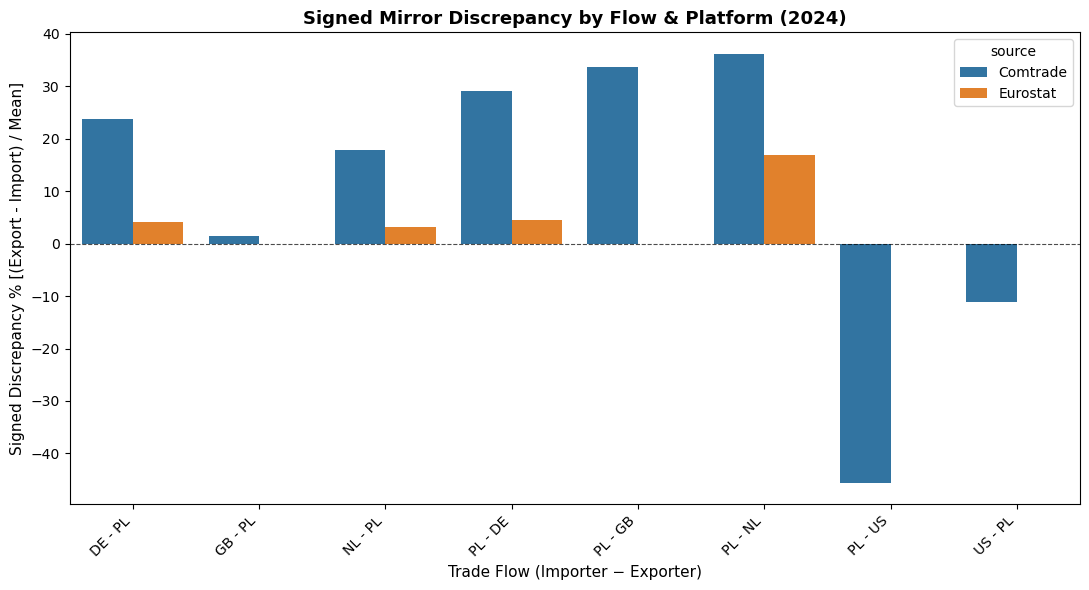

In [66]:
plt.figure(figsize=(11, 6))
ax = sns.barplot(
    data=direction_totals,
    x="relation",
    y="signed_discrepancy_pct",
    hue="source"
)
plt.axhline(0, color="black", linestyle="--", linewidth=0.8, alpha=0.7)
ax.set_title("Signed Mirror Discrepancy by Flow & Platform (2024)", fontsize=13, weight="bold")
ax.set_xlabel("Trade Flow (Importer − Exporter)", fontsize=11)
ax.set_ylabel("Signed Discrepancy % [(Export - Import) / Mean]", fontsize=11)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [67]:
direction_totals_gap = direction_totals[direction_totals["source"] == "Comtrade"].merge(direction_totals[direction_totals["source"] == "Eurostat"], on=["importer","exporter"], suffixes=("_comtrade","_eurostat"))
direction_totals_gap["import_side_gap"] = abs((direction_totals_gap["total_import_comtrade"]-direction_totals_gap["total_import_eurostat"])/((direction_totals_gap["total_import_comtrade"]+direction_totals_gap["total_import_eurostat"])/2)*100)
direction_totals_gap["export_side_gap"] = abs((direction_totals_gap["total_export_comtrade"]-direction_totals_gap["total_export_eurostat"])/((direction_totals_gap["total_export_comtrade"]+direction_totals_gap["total_export_eurostat"])/2)*100)
direction_totals_gap_summary = direction_totals_gap[["relation_comtrade","import_side_gap","export_side_gap"]]
direction_totals_gap_summary

,relation_comtrade,import_side_gap,export_side_gap
0,DE - PL,20.70,0.98
1,NL - PL,15.54,0.81
2,PL - DE,27.60,3.02
3,PL - NL,51.83,33.11


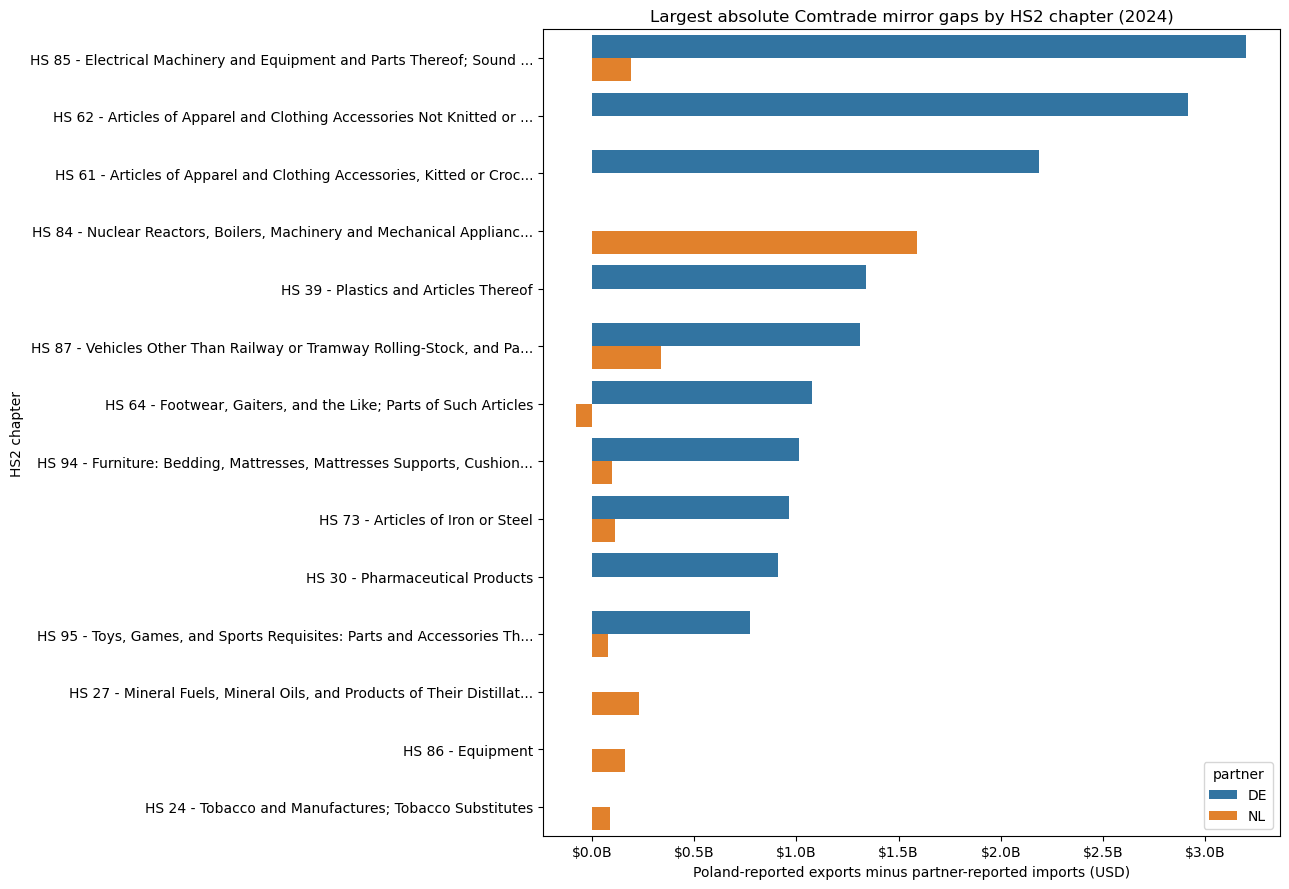

In [68]:
top_HS2_DE = comtrade[comtrade["partner"]=="DE"].sort_values("gap", key=abs, ascending=False).head(10)
top_HS2_NL = comtrade[comtrade["partner"]=="NL"].sort_values("gap", key=abs, ascending=False).head(10)
top_HS2_contributors = pd.concat([top_HS2_DE,top_HS2_NL], ignore_index=True).sort_values("gap",key=abs, ascending=False)
top_HS2_contributors["hs2_label_chart"]= "HS " + top_HS2_contributors["hs2"] + " - " + top_HS2_contributors["hs2_label"].apply(lambda x: x[:60] + "..." if len(x) > 60 else x)
plt.figure(figsize=(13, 9))
ax = sns.barplot(data=top_HS2_contributors, x="gap", y="hs2_label_chart", hue="partner")
ax.set_title("Largest absolute Comtrade mirror gaps by HS2 chapter (2024)")
ax.set_xlabel("Poland-reported exports minus partner-reported imports (USD)")
ax.set_ylabel("HS2 chapter")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"${value / 1e9:.1f}B"))
plt.tight_layout()
plt.show()

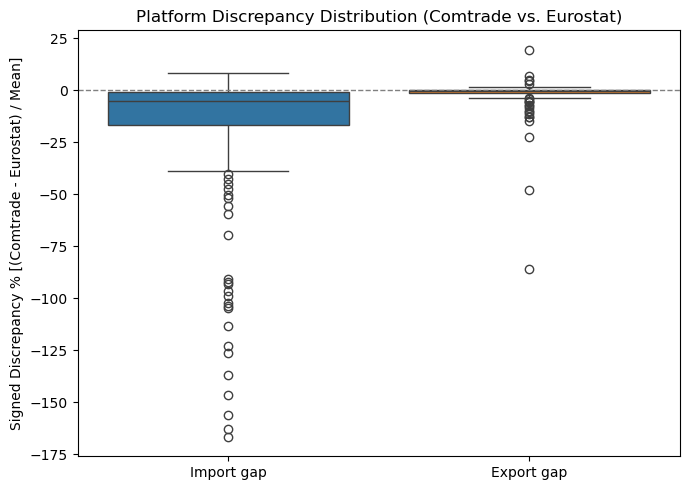

In [69]:
source_asymmetry = comtrade_vs_eurostat_hs2_comparison[["comtrade_vs_eurostat_hs2_import_gap", "comtrade_vs_eurostat_hs2_export_gap"]].rename(columns={"comtrade_vs_eurostat_hs2_import_gap":"Import gap","comtrade_vs_eurostat_hs2_export_gap":"Export gap"})
plt.figure(figsize=(7, 5))
sns.boxplot(data=source_asymmetry)
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.ylabel("Signed Discrepancy % [(Comtrade - Eurostat) / Mean]")
plt.title("Platform Discrepancy Distribution (Comtrade vs. Eurostat)")
plt.tight_layout()
plt.show()

## Methodology & Limitations

What "discrepancy" means here. For every mirror pair, gap is the signed difference (exporter's declared value minus importer's declared value); discrepancy_pct expresses that gap as a percentage of the average of the two figures, not either one alone — this keeps large and small trade flows comparable on the same scale. All chapter-level rankings apply a $100M minimum (on at least one side of the flow) before sorting by percentage, to avoid low-volume chapters producing extreme, meaningless percentage swings.

Why exporter and importer figures diverge even when neither side is wrong. Several mechanical, well-documented sources of divergence apply here, independent of any data quality issue:

Valuation basis (FOB vs. CIF). By UN/WCO statistical convention, exports are recorded FOB (at the border, before onward freight and insurance) while imports are recorded CIF (including freight and insurance to the destination border) — a structural gap that exists even for a perfectly-reported shipment. This normally makes imports slightly higher than exports, so the large Germany gap in the opposite direction points to additional mechanisms rather than freight and insurance alone.
Intrastat exemption thresholds. Each EU member state sets its own annual value threshold below which businesses aren't required to file Intrastat declarations; trade below that threshold is estimated rather than directly declared, and estimation methods vary by country.
Reporting timing. The exporting country typically records a shipment when goods leave its territory; the importing country records it on customs clearance, which can be days or weeks later — this can shift large, lumpy shipments into different reporting periods on each side.
Re-exports and country attribution. A partner country can be recorded by where goods were shipped from (consignment) or where they originated (origin) — not always the same country. This is particularly relevant to the Netherlands leg of this analysis, given Rotterdam's role as a major European re-export hub.

On the recurring HS85/87 finding. Electrical machinery (HS85) and vehicles (HS87) recur as material discrepancy contributors across the Germany, USA, and Eurostat comparisons in this analysis. This is a documented pattern of recurrence, not a demonstrated cause — the data here shows these chapters keep appearing, not why. A plausible candidate explanation is the complexity of multi-stage global supply chains in these sectors (components crossing borders multiple times before final assembly), but that mechanism is not tested directly in this analysis and should be treated as a hypothesis for further investigation rather than a conclusion.

## Summary of findings

Country attribution is a leading, documented explanation for the very large Comtrade-versus-Eurostat import-side differences in apparel, footwear and toys. Eurostat defines the partner for intra-EU imports as the Member State of consignment. UN Comtrade's first partner for imports is country of origin; this analysis requests `partner2Code=0`, so it uses that first-partner view. A shipment dispatched from Poland to Germany but originating elsewhere can therefore be attributed to Poland in Eurostat and to its origin country in Comtrade. This mechanism is consistent with the observed pattern, but this aggregate analysis cannot prove that it drives any individual chapter; doing so would require transaction-level origin and consignment data.
Partner-level: mirror discrepancies range from ~1.4% (UK) to ~45.6% (Poland→USA), with no single partner or direction consistently near zero.
Germany vs. Netherlands: both show materially large chapter-level gaps despite modest aggregate discrepancies, but Netherlands shows a pronounced direction asymmetry (17.9% one way, 36.2% the reverse) not present for Germany — consistent with, though not proof of, a re-export effect.
Commodity-level: electrical machinery (85) and vehicles (87) are the largest absolute-dollar contributors across partners; apparel, footwear, and toys (61/62/64/95) show the most extreme relative divergence between Comtrade and Eurostat specifically.
What the platform comparison proves, and doesn't: Comtrade and Eurostat report Poland's own export declarations almost identically (under ~3% apart); they diverge substantially on the partner's import-side figure for the same flow. This shows the two platforms are not independent measurements of import data — it does not establish which platform's import figure is more accurate, only that the disagreement sits specifically on the import side.